In [6]:
import pandas as pd
import sklearn
import itertools
import numpy as np
import seaborn as sb
import re
import nltk
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from matplotlib import pyplot as plt
from sklearn.linear_model import PassiveAggressiveClassifier
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [7]:

train_df = pd.read_csv(r'/content/train.csv')

In [8]:
train_df.head(15)

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1
5,5,Jackie Mason: Hollywood Would Love Trump if He...,Daniel Nussbaum,"In these trying times, Jackie Mason is the Voi...",0
6,6,Life: Life Of Luxury: Elton John’s 6 Favorite ...,NaN,Ever wonder how Britain’s most iconic pop pian...,1
7,7,Benoît Hamon Wins French Socialist Party’s Pre...,Alissa J. Rubin,"PARIS — France chose an idealistic, traditi...",0
8,8,Excerpts From a Draft Script for Donald Trump’...,NaN,Donald J. Trump is scheduled to make a highly ...,0
9,9,"A Back-Channel Plan for Ukraine and Russia, Co...",Megan Twohey and Scott Shane,A week before Michael T. Flynn resigned as nat...,0


In [9]:

train_df = train_df.drop("author", axis = 1)
train_df = train_df.drop("title", axis = 1)
train_df = train_df.drop("id", axis = 1)

In [10]:
train_df.shape

(20800, 2)

In [11]:
train_df.head(15)

,text,label
0,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,Ever get the feeling your life circles the rou...,0
2,"Why the Truth Might Get You Fired October 29, ...",1
3,Videos 15 Civilians Killed In Single US Airstr...,1
4,Print \nAn Iranian woman has been sentenced to...,1
5,"In these trying times, Jackie Mason is the Voi...",0
6,Ever wonder how Britain’s most iconic pop pian...,1
7,"PARIS — France chose an idealistic, traditi...",0
8,Donald J. Trump is scheduled to make a highly ...,0
9,A week before Michael T. Flynn resigned as nat...,0


In [12]:
train_df.isna().sum()

,0
text,39
label,0


<ipython-input-13-50ac62bd966a>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  return sb.countplot(x='label', data=dataFile, palette='hls')


<Axes: xlabel='label', ylabel='count'>

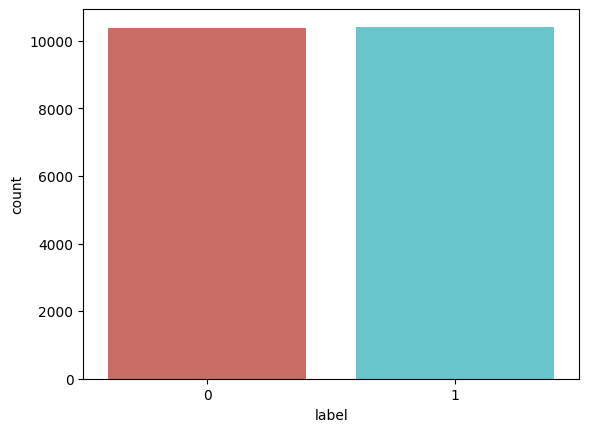

In [13]:
def create_distribution(dataFile):
    return sb.countplot(x='label', data=dataFile, palette='hls')


create_distribution(train_df)

In [14]:
def data_qualityCheck():
    print("Checking data qualitites...")
    train_df.isnull().sum()
    train_df.info()
    print("check finished.")
data_qualityCheck()


Checking data qualitites...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    20761 non-null  object
 1   label   20800 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 325.1+ KB
check finished.


In [15]:
train_df = train_df.dropna()

In [16]:
data_qualityCheck()

Checking data qualitites...
<class 'pandas.core.frame.DataFrame'>
Index: 20761 entries, 0 to 20799
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    20761 non-null  object
 1   label   20761 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 486.6+ KB
check finished.


In [17]:
train_df.shape

(20761, 2)

In [18]:
train_df.head(10)

,text,label
0,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,Ever get the feeling your life circles the rou...,0
2,"Why the Truth Might Get You Fired October 29, ...",1
3,Videos 15 Civilians Killed In Single US Airstr...,1
4,Print \nAn Iranian woman has been sentenced to...,1
5,"In these trying times, Jackie Mason is the Voi...",0
6,Ever wonder how Britain’s most iconic pop pian...,1
7,"PARIS — France chose an idealistic, traditi...",0
8,Donald J. Trump is scheduled to make a highly ...,0
9,A week before Michael T. Flynn resigned as nat...,0


In [19]:
train_df.reset_index(drop= True,inplace=True)

In [20]:
train_df.head(10)

,text,label
0,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,Ever get the feeling your life circles the rou...,0
2,"Why the Truth Might Get You Fired October 29, ...",1
3,Videos 15 Civilians Killed In Single US Airstr...,1
4,Print \nAn Iranian woman has been sentenced to...,1
5,"In these trying times, Jackie Mason is the Voi...",0
6,Ever wonder how Britain’s most iconic pop pian...,1
7,"PARIS — France chose an idealistic, traditi...",0
8,Donald J. Trump is scheduled to make a highly ...,0
9,A week before Michael T. Flynn resigned as nat...,0


In [21]:
label_train = train_df.label

In [22]:
label_train = train_df.label

In [23]:
train_df = train_df.drop("label", axis = 1)

In [24]:
train_df.head(10)

,text
0,House Dem Aide: We Didn’t Even See Comey’s Let...
1,Ever get the feeling your life circles the rou...
2,"Why the Truth Might Get You Fired October 29, ..."
3,Videos 15 Civilians Killed In Single US Airstr...
4,Print \nAn Iranian woman has been sentenced to...
5,"In these trying times, Jackie Mason is the Voi..."
6,Ever wonder how Britain’s most iconic pop pian...
7,"PARIS — France chose an idealistic, traditi..."
8,Donald J. Trump is scheduled to make a highly ...
9,A week before Michael T. Flynn resigned as nat...


In [25]:
train_df['text'][2188]

'\nThis article was written by John Vibes and originally published at Activist Post.com . \nEditor’s Comment: On the surface, there are good intentions here. The Bushes, like other patriotic establishment figures, always honor the troops, and count the sacrifices. Typically, they are stoic and praiseworthy of everything the military does. But underneath the surface, one has to wonder what is really going on inside the disturbed mind of George W. Bush – whose orders for an illegal war in Iraq, and a broader War on Terror in Afghanistan and elsewhere resulted in the deaths of thousands of U.S. troops, tens of thousands of wounded or injured and potentially more than a million civilians dead. \nDoes he feel remorse? Guilt? Has he admitted to his personal responsibility for what happened to their lives? Or do his paintings reveal a morbid sense of power over the lives of men and women whom he can only reflect upon and humanize after the fact? Considering that the Iraq war was based upon a 

In [26]:
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('stopwords')
lemmatizer = WordNetLemmatizer()
stpwrds = list(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [27]:
stpwrds

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [28]:
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('stopwords')
nltk.download('punkt') # Download the 'punkt' package
lemmatizer = WordNetLemmatizer()
stpwrds = list(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [29]:
train_df['text'][2182]

'Comments Actor Steven Seagal has just stood up for America, while the rest of Hollywood remains silent. This week has been rough for our country. First, Democratic nominee Hillary Clinton collapsed at the 9/11 memorial. Then, she called millions of hardworking Americans “deplorable.” As if that weren’t enough, NFL players throughout the country have been blatantly disrespecting the American flag. Needless to say, Seagal had enough. “I think the most important job as Secretary of State is ensuring our people don’t get killed,” Seagal tweeted. “If you can’t do [email protected] “Pneumonia or not, she is going to be disastrous for the American people. #NoToHillary,” he continued. Of course, Seagal quickly became the target of liberal fire for his comments, but he refused to break down. He particularly lost it when one Twitter user tried to argued that Hillary was the most capable for the presidency. “Capable? Capable of leaving AMERICANS to die. Capable of disregarding law. Capable of di

In [30]:
#splitting the dataset to training and test dataset,80% data to be training data &20% will be testing data.(ie test_size=0.2)
X_train, X_test, Y_train, Y_test = train_test_split(train_df['text'], label_train, test_size=0.2, random_state=0)

In [31]:
X_train

,text
11948,"ATLANTA — The report, written on notebo..."
5370,"Naming Trump, Nigel Farage in Britain and Mari..."
1179,"Merkel says Facebook, Google ‘distort percepti..."
15032,"GERMANY: “We are Somali Muslims, we don’t have..."
13850,"Hillary Clinton, FBI and the Real November Su..."
...,...
13123,"Share on Facebook I don't know about you, but ..."
19648,A Berkeley student argues that free speech put...
9845,With Justice Neil Gorsuch now seated on the Su...
10799,"Leave a reply \nBill Still – Good morning, I’m..."


In [32]:
X_train.shape

(16608,)

In [33]:
Y_train

,label
11948,0
5370,1
1179,1
15032,1
13850,1
...,...
13123,1
19648,0
9845,0
10799,1


In [34]:
#converting to textual data into numerical data/feature vector

tfidf_v = TfidfVectorizer()
tfidf_X_train = tfidf_v.fit_transform(X_train)
tfidf_X_test = tfidf_v.transform(X_test)

In [35]:
print(tfidf_X_train,tfidf_X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5488836 stored elements and shape (16608, 162248)>
  Coords	Values
  (0, 11308)	0.03194499746251017
  (0, 124048)	0.24226840660308796
  (0, 104744)	0.01733243873851775
  (0, 137333)	0.021800539610408034
  (0, 89411)	0.07308583396376526
  (0, 87461)	0.041475385652959294
  (0, 92093)	0.024047310753346034
  (0, 20656)	0.02189424926915963
  (0, 8042)	0.04687407050902269
  (0, 40524)	0.06823858861989582
  (0, 110341)	0.16825464023382528
  (0, 119555)	0.0732732230313579
  (0, 61613)	0.1030506354954085
  (0, 23827)	0.13717835790012606
  (0, 123488)	0.042583970616721104
  (0, 10366)	0.02387478942916139
  (0, 87555)	0.07669802577863291
  (0, 723)	0.04314139177861858
  (0, 20428)	0.29090063902536906
  (0, 38231)	0.1674788448440838
  (0, 38235)	0.03437494105078922
  (0, 45599)	0.05147127062015234
  (0, 136948)	0.28480017520883194
  (0, 137354)	0.0853918942724191
  (0, 88775)	0.08894158830800365
  :	:
  (16607, 5267)	0.04876054310000157

In [36]:
print(tfidf_X_train,tfidf_X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5488836 stored elements and shape (16608, 162248)>
  Coords	Values
  (0, 11308)	0.03194499746251017
  (0, 124048)	0.24226840660308796
  (0, 104744)	0.01733243873851775
  (0, 137333)	0.021800539610408034
  (0, 89411)	0.07308583396376526
  (0, 87461)	0.041475385652959294
  (0, 92093)	0.024047310753346034
  (0, 20656)	0.02189424926915963
  (0, 8042)	0.04687407050902269
  (0, 40524)	0.06823858861989582
  (0, 110341)	0.16825464023382528
  (0, 119555)	0.0732732230313579
  (0, 61613)	0.1030506354954085
  (0, 23827)	0.13717835790012606
  (0, 123488)	0.042583970616721104
  (0, 10366)	0.02387478942916139
  (0, 87555)	0.07669802577863291
  (0, 723)	0.04314139177861858
  (0, 20428)	0.29090063902536906
  (0, 38231)	0.1674788448440838
  (0, 38235)	0.03437494105078922
  (0, 45599)	0.05147127062015234
  (0, 136948)	0.28480017520883194
  (0, 137354)	0.0853918942724191
  (0, 88775)	0.08894158830800365
  :	:
  (16607, 5267)	0.04876054310000157

In [37]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [38]:
#model and model training

classifier = PassiveAggressiveClassifier()
classifier.fit(tfidf_X_train,Y_train)

PassiveAggressiveClassifier()

Accuracy: 96.68%
Confusion matrix, without normalization


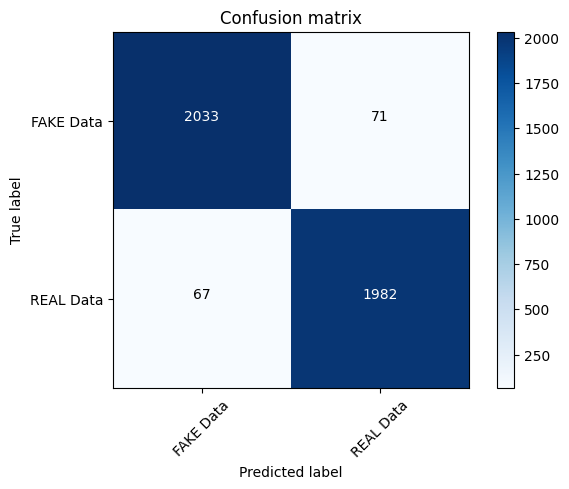

In [39]:
#accuracy score on the test data
Y_pred = classifier.predict(tfidf_X_test)
score = metrics.accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {round(score*100,2)}%')
cm = metrics.confusion_matrix(Y_test, Y_pred)
plot_confusion_matrix(cm, classes=['FAKE Data', 'REAL Data'])

In [40]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2104
           1       0.97      0.97      0.97      2049

    accuracy                           0.97      4153
   macro avg       0.97      0.97      0.97      4153
weighted avg       0.97      0.97      0.97      4153



In [41]:

pickle.dump(classifier,open('./model.pkl', 'wb'))
pickle.dump(tfidf_v,open('vector.pkl', 'wb'))

In [42]:

loaded_model = pickle.load(open('./model.pkl', 'rb'))


In [43]:
def fake_news_det(news):
    review = news
    review = re.sub(r'[^a-zA-Z\s]', '', review)
    review = review.lower()
    review = nltk.word_tokenize(review)
    corpus = []
    for y in review :
        if y not in stpwrds :
            corpus.append(lemmatizer.lemmatize(y))
    input_data = [' '.join(corpus)]
    vectorized_input_data = tfidf_v.transform(input_data)
    prediction = loaded_model.predict(vectorized_input_data)
    if prediction[0] == 1:
        print("Prediction of the News :  Looking Fake⚠ News📰 ")
    else:
        print("Prediction of the News : Looking Real News📰 ")

In [44]:
X_test

,text
9383,JERUSALEM — “Mr. President!” a woman called...
1471,MILO’s upcoming book DANGEROUS has jumped to t...
4480,NEW DELHI — India’s rapidly worsening air p...
17543,There is nothing presidential (in a dignified ...
775,"On Thursday, Republican Senators Ted Cruz ( ) ..."
...,...
11562,CAIRO — One of Egypt’s highest courts overt...
18758,A bill in Congress could make it harder for wo...
19925,Email \nRebutting the Justice Department’s ass...
16765,You used to need $10 million to become a custo...


In [45]:
X_test.iloc[4152]

'WASHINGTON, Conn.  —   In 1999, a television writer named Amy   vacationed at the Mayflower Grace, a   inn built high on a hill here. In true Hollywood fashion, Ms.   returned to her hometown, Los Angeles, and from her brief visit spun Stars Hollow  —   a charming New England small town with its own resident troubadour. Stars Hollow would become the setting for “Gilmore Girls,” her cultishly popular   dramedy that ran for seven seasons on the WB (and later the CW). Last weekend, more than 1, 300 fans, most of them women, many of them mothers and daughters, descended on this rural town in western Connecticut (population: 3, 500) for the first Gilmore Girls Fan Fest. They had come from Oklahoma and Minnesota and as far away as Brazil  —   and paid as much as $250 per ticket  —   to see the “real” Stars Hollow and meet some of the actors who play its residents. In a way, they wanted to do the impossible: to experience in waking life a dream town built on a studio backlot. In Stars Hollow

In [46]:
new_var = Y_test.iloc[4152]

In [47]:
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Download the 'punkt_tab' package
lemmatizer = WordNetLemmatizer()
stpwrds = list(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [48]:
import nltk

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
news=str(input("Enter the News:"))
fake_news_det(news)

In [ ]:
print(tfidf_X_test)

In [ ]:
print(Y_test.iloc[4152])

In [ ]:
X_new=tfidf_X_test[3]
prediction = loaded_model.predict(X_new)

if (prediction[0] == 1):
	print("Prediction of the News :  Looking Fake⚠ News📰 ")
else:
	print("Prediction of the News : Looking Real News📰 ")

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.1/323.1 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.5 MB/s eta 0:00:00


In [ ]:
import gradio as gr
import pickle

# Load the trained model
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

# Load the vectorizer
# Changed 'vectorizer.pkl' to 'vector.pkl'
with open('vector.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# Function to predict real or fake news
def predict_news(text):
    if not text.strip():
        return "Please enter some news content."

    transformed_text = vectorizer.transform([text])
    prediction = model.predict(transformed_text)

    return "🟢 Real News" if prediction[0] == 1 else "🔴 Fake News"

# Gradio Interface
iface = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(lines=10, label="Enter News Article Text"),
    outputs=gr.Textbox(label="Prediction"),
    title="📰 Fake News Detector",
    description="Paste a news article below to check if it is REAL or FAKE using a trained ML model."
)

iface.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://31a2c31d9a169b4859.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
